In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pras1511/flower-photos/flower_photos.tgz


In [2]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

2026-06-06 10:13:56.575587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780740836.825900     102 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780740836.895386     102 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780740837.464985     102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780740837.465059     102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780740837.465062     102 computation_placer.cc:177] computation placer alr

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [4]:
data_dir

'./datasets/flower_photos'

In [5]:
import tarfile

tar_path = '/kaggle/input/datasets/pras1511/flower-photos/flower_photos.tgz'

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall('/kaggle/working/')

/tmp/ipykernel_102/3057635675.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/kaggle/working/')


In [6]:
import pathlib

data_dir = pathlib.Path('/kaggle/working/flower_photos')

print(data_dir)

/kaggle/working/flower_photos


In [7]:
print(list(data_dir.iterdir()))

[PosixPath('/kaggle/working/flower_photos/roses'), PosixPath('/kaggle/working/flower_photos/sunflowers'), PosixPath('/kaggle/working/flower_photos/daisy'), PosixPath('/kaggle/working/flower_photos/LICENSE.txt'), PosixPath('/kaggle/working/flower_photos/dandelion'), PosixPath('/kaggle/working/flower_photos/tulips')]


In [8]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [9]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('/kaggle/working/flower_photos/roses/2265390547_2409007cef_n.jpg'),
 PosixPath('/kaggle/working/flower_photos/roses/3621011057_0d03bd171b_n.jpg'),
 PosixPath('/kaggle/working/flower_photos/roses/17062080069_36ac7907d2_n.jpg'),
 PosixPath('/kaggle/working/flower_photos/roses/512694812_48ba9c0b49_n.jpg'),
 PosixPath('/kaggle/working/flower_photos/roses/22506717337_0fd63e53e9.jpg')]

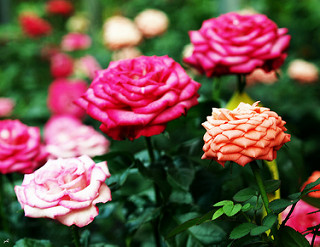

In [10]:
Image.open(str(roses[1]))

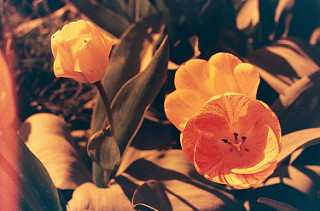

In [11]:
tulips = list(data_dir.glob('tulips/*'))
Image.open(str(tulips[0]))

In [12]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [13]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [14]:
# converting images into pixel values with CNN can understand

X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

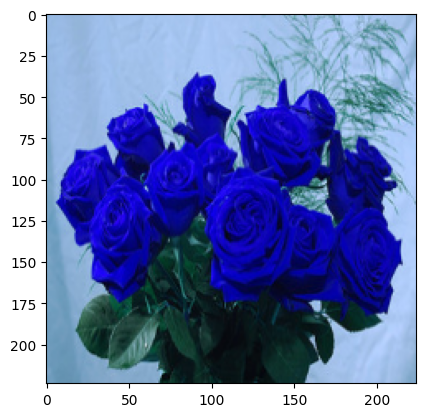

In [16]:
plt.imshow(X[0])

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
X = np.array(X)
y = np.array(y)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train.shape,X_test.shape

((2569, 224, 224, 3), (1101, 224, 224, 3))

In [22]:
cnn = Sequential([
    layers.Rescaling(1./255,input_shape=(224,224,3)),
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=42,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(60,activation='relu'),
    layers.Dense(70,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

cnn.fit(X_train,y_train,epochs = 10)

cnn.evaluate(X_test,y_test)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.4757 - loss: 1.3305
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6166 - loss: 0.9595
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7711 - loss: 0.6515
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9054 - loss: 0.3201
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9638 - loss: 0.1392
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9860 - loss: 0.0591
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9778 - loss: 0.0910
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9751 - loss: 0.1136
Epoch 9/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9957 - loss: 0.0184
Epoch 10/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9953 - loss: 0.0202
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 343ms/step - accuracy: 0.5840 - loss: 2.1587


[2.1587085723876953, 0.5840145349502563]

In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])

In [46]:
cnn1 = Sequential([
    layers.Rescaling(1./255,input_shape=(224,224,3)),
    data_augmentation,
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=42,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(60,activation='relu'),
    layers.Dense(70,activation='relu'),
    layers.Dense(10,activation='softmax')
])

cnn1.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

cnn1.fit(X_train,y_train,epochs = 10)

cnn1.evaluate(X_test,y_test)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4582 - loss: 1.3625
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5827 - loss: 1.0845
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6232 - loss: 0.9681
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6617 - loss: 0.8986
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6870 - loss: 0.8237
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7174 - loss: 0.7558
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7147 - loss: 0.7400
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7373 - loss: 0.6995
Epoch 9/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7614 - loss: 0.6239
Epoch 10/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7824 - loss: 0.6058
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - accuracy: 0.6676 - loss: 0.8931


[0.8930731415748596, 0.667574942111969]

In [50]:
y_pred1 = cnn.predict(X_test)
y_pred1 = np.argmax(y_pred1, axis = 1)

y_pred2 = cnn1.predict(X_test)
y_pred2 = np.argmax(y_pred2, axis = 1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 346ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step


              precision    recall  f1-score   support

           0       0.50      0.49      0.50       216
           1       0.60      0.44      0.51       192
           2       0.60      0.67      0.64       261
           3       0.69      0.72      0.71       204
           4       0.53      0.57      0.55       228

    accuracy                           0.58      1101
   macro avg       0.59      0.58      0.58      1101
weighted avg       0.58      0.58      0.58      1101

              precision    recall  f1-score   support

           0       0.56      0.66      0.61       216
           1       0.88      0.43      0.58       192
           2       0.66      0.86      0.75       261
           3       0.72      0.76      0.74       204
           4       0.66      0.57      0.61       228

    accuracy                           0.67      1101
   macro avg       0.70      0.66      0.66      1101
weighted avg       0.69      0.67      0.66      1101



<Axes: >

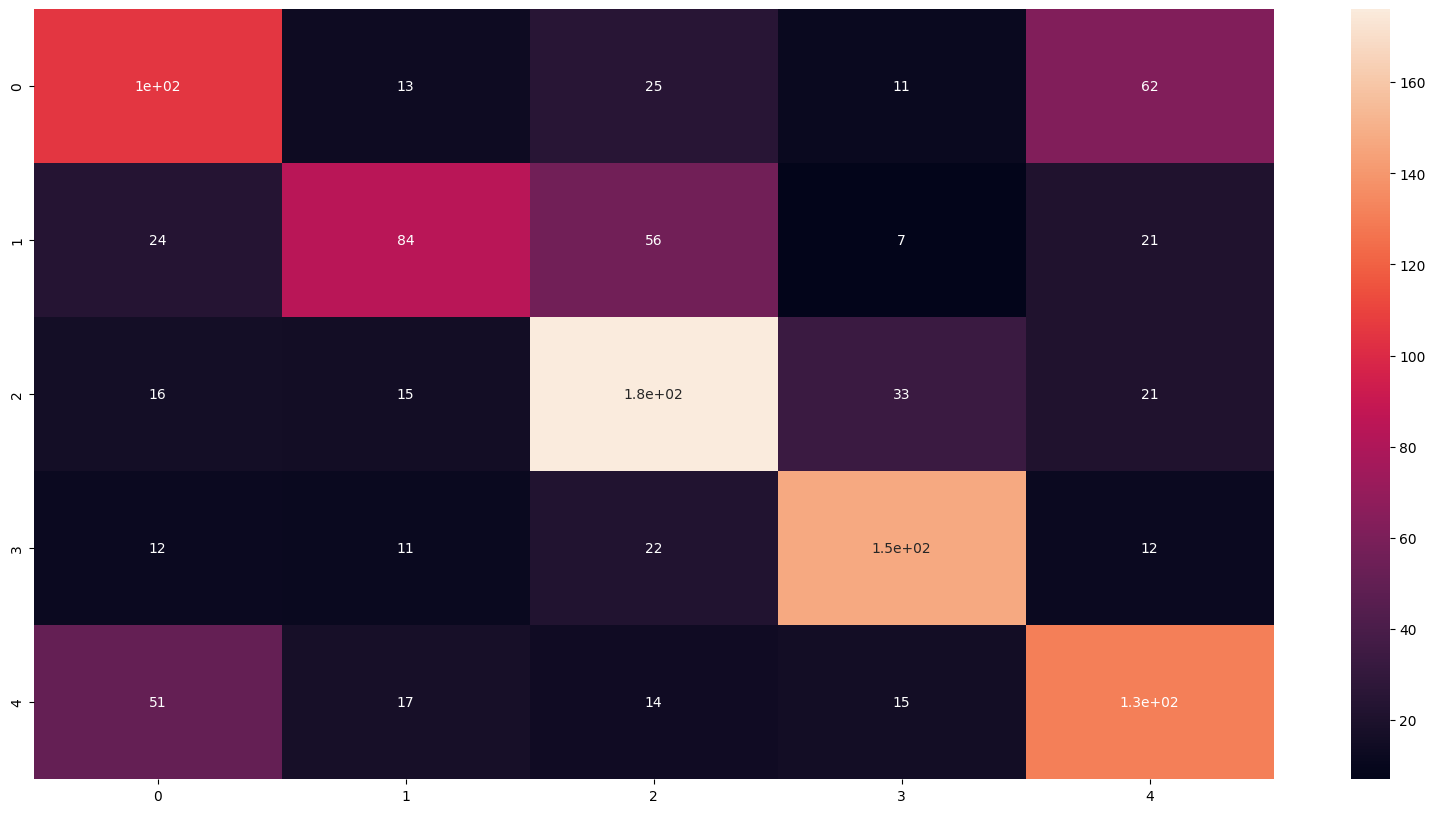

In [51]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred1))
print(classification_report(y_test,y_pred2))

cm1 = confusion_matrix(y_test,y_pred1)
cm2 = confusion_matrix(y_test,y_pred2)

import seaborn as sns
plt.figure(figsize=(20,10))
sns.heatmap(cm1,annot=True)

<Axes: >

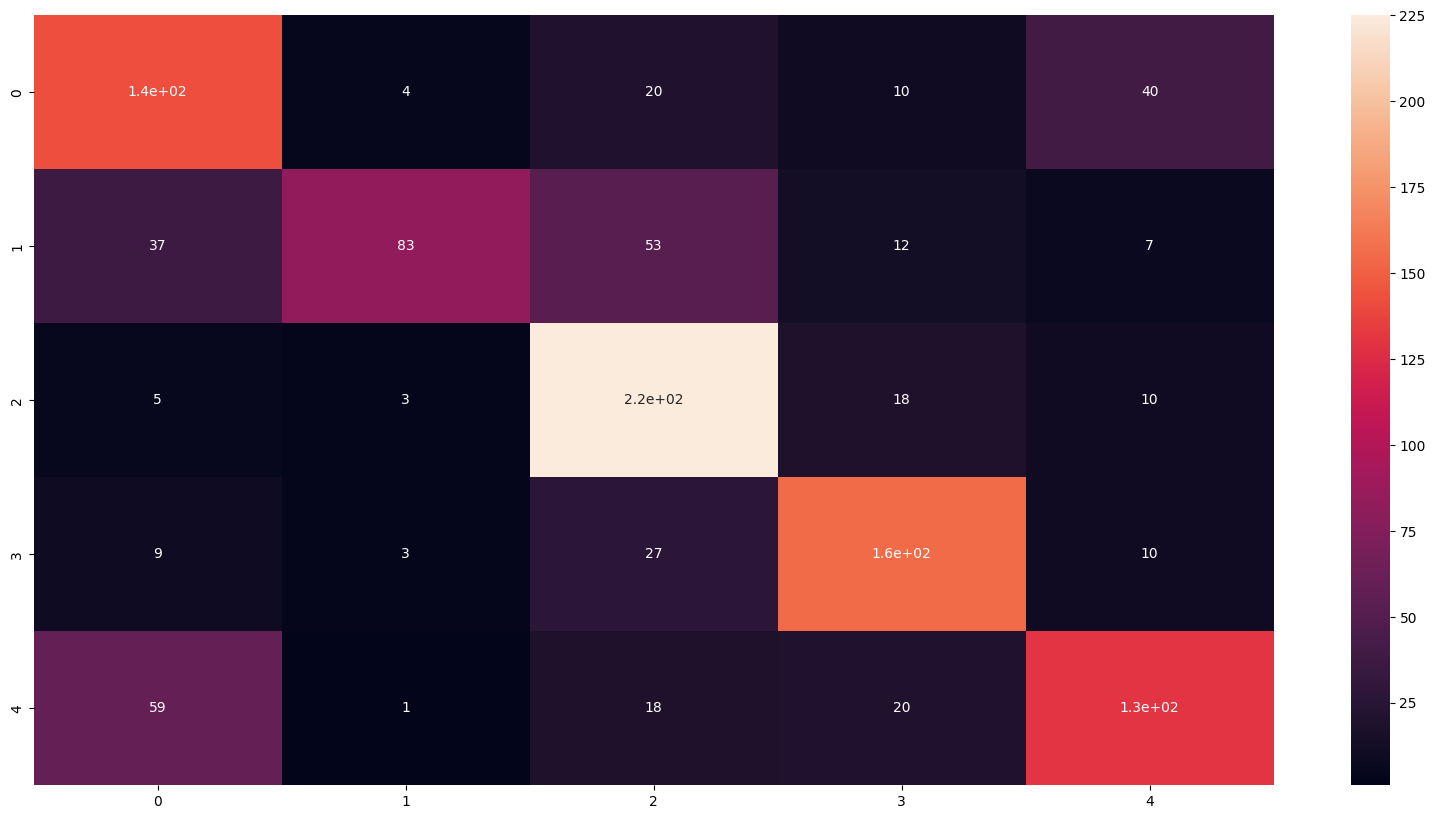

In [52]:
plt.figure(figsize=(20,10))
sns.heatmap(cm2,annot=True)

In [54]:
result = cnn.predict(X[0][np.newaxis,...])
pred = np.argmax(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [55]:
pred

np.int64(4)

In [57]:
result = cnn1.predict(X[1879][np.newaxis,...])
np.argmax(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


np.int64(2)

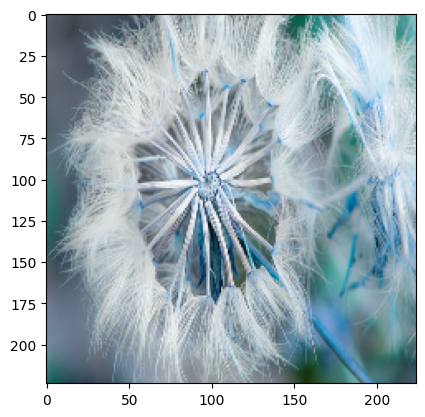

In [59]:
plt.imshow(X[1879])

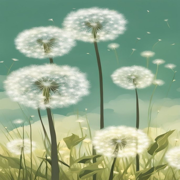

In [60]:
Image.open('/kaggle/input/datasets/pras1511/dandilion-from-online/Dandelion Sun Background.jpg').resize((180,180))

In [61]:
dandilion = Image.open('/kaggle/input/datasets/pras1511/dandilion-from-online/Dandelion Sun Background.jpg').resize((224,224))
dandilion = np.array(dandilion)
dandilion.shape

(224, 224, 3)

In [62]:
pred_dandilion = cnn1.predict(dandilion[np.newaxis,...])
np.argmax(pred_dandilion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


np.int64(2)